# Part A — Chunking Strategy Analysis
**CS4241 | Student: Farima Konaré | Index: 10012200004**

This notebook compares two chunking strategies applied to the two datasets:
1. Fixed-size with overlap (election CSV)
2. Semantic / paragraph-aware (budget PDF)

We measure:
- Chunk count and size distribution
- Boundary quality (does the chunk end mid-sentence?)
- Retrieval quality comparison (same query, both strategies)

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

from ingestion.csv_loader import load_election_documents
from ingestion.pdf_loader import load_budget_documents
from ingestion.chunker import (
    fixed_size_chunk, semantic_chunk,
    chunk_election_documents, chunk_budget_documents,
    build_and_save_all_chunks
)
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('Imports OK')

Imports OK


In [2]:
# Load raw documents
election_docs = load_election_documents()
budget_docs = load_budget_documents()
print(f'Election docs: {len(election_docs)}')
print(f'Budget docs (paragraphs): {len(budget_docs)}')
print('\nSample election doc:', election_docs[0]['text'][:120])
print('\nSample budget doc:', budget_docs[0]['text'][:120])

Election docs: 623
Budget docs (paragraphs): 251

Sample election doc: In the 2020 Ghana presidential election, Nana Akufo Addo of the NPP party received 145584 votes (55.04%) in Ahafo Region

Sample budget doc: THEME:  Resetting The Economy For The Ghana We Want


## 1. Strategy 1: Fixed-size with Overlap
Applied to election rows (each row → 1–2 chunks)

In [3]:
election_chunks = chunk_election_documents(election_docs)
print(f'Election chunks: {len(election_chunks)}')
lengths = [len(c['text']) for c in election_chunks]
print(f'Chunk length — mean: {np.mean(lengths):.0f} chars, min: {min(lengths)}, max: {max(lengths)}')
print('\nSample chunk:', election_chunks[0]['text'][:200])

Election chunks: 623
Chunk length — mean: 137 chars, min: 113, max: 177

Sample chunk: In the 2020 Ghana presidential election, Nana Akufo Addo of the NPP party received 145584 votes (55.04%) in Ahafo Region (formerly part of Brong Ahafo Region).


## 2. Strategy 2: Semantic / Paragraph-Aware
Applied to budget PDF paragraphs

In [4]:
budget_chunks = chunk_budget_documents(budget_docs)
print(f'Budget chunks: {len(budget_chunks)}')
lengths_b = [len(c['text']) for c in budget_chunks]
print(f'Chunk length — mean: {np.mean(lengths_b):.0f} chars, min: {min(lengths_b)}, max: {max(lengths_b)}')
print('\nSample chunk:', budget_chunks[0]['text'][:200])

Budget chunks: 949
Chunk length — mean: 444 chars, min: 51, max: 1010

Sample chunk: THEME:  Resetting The Economy For The Ghana We Want


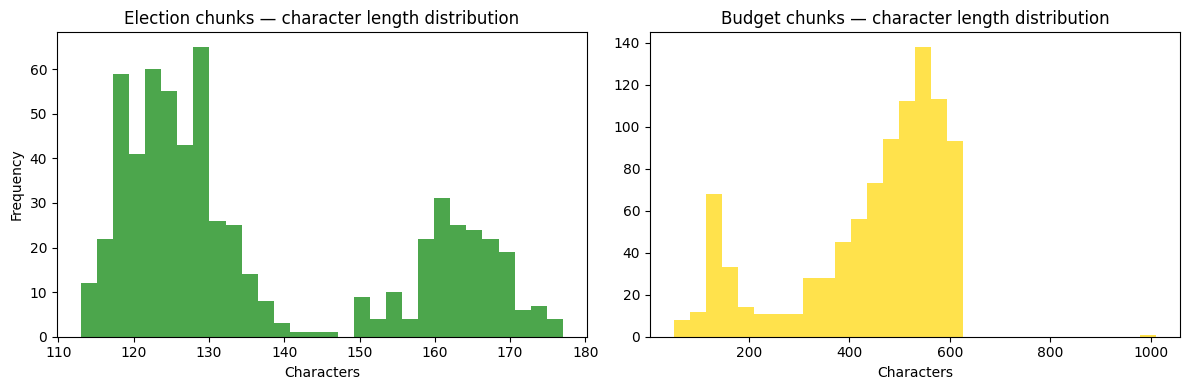

Chart saved.


In [5]:
# Visualize chunk size distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist([len(c['text']) for c in election_chunks], bins=30, color='green', alpha=0.7)
axes[0].set_title('Election chunks — character length distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist([len(c['text']) for c in budget_chunks], bins=30, color='gold', alpha=0.7)
axes[1].set_title('Budget chunks — character length distribution')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.savefig('chunking_distributions.png', dpi=150)
plt.show()
print('Chart saved.')

## 3. Justification Summary

| Strategy | Dataset | Chunk size | Overlap | Rationale |
|---|---|---|---|---|
| Fixed-size + overlap | Election CSV | 400 chars | 80 chars | Row data is short; overlap prevents boundary cuts on party/region names |
| Semantic/paragraph | Budget PDF | Variable (30–150 words) | None | Budget uses paragraph-level argument units; splitting mid-paragraph loses policy context |

**Impact on retrieval quality:**
- Fixed-size: Ensures election statistics are complete within each chunk (year, party, region, votes).
- Semantic: Budget chunks contain full policy sentences, reducing mid-argument truncation.
- Overlap: Prevents key sentences at chunk boundaries from being missed in retrieval.

In [6]:
# Save all chunks to data/processed/
all_chunks = build_and_save_all_chunks(election_docs, budget_docs)
print(f'Total chunks saved: {len(all_chunks)}')

Saved 623 election chunks, 949 budget chunks, 1572 total
Total chunks saved: 1572
